## **Práctica Numérica 2**
# Física Computacional
# Andrés Alexander Rivera Zelaya (RZ22004)
Se espera que la dispersión de una partícula proyectil por un centro de fuerza sea un proceso continuo. Sin embargo, en algunas situaciones la partícula experimenta múltiples dispersiones internas y termina con una trayectoria final que parece no estar relacionada con la inicial. En particular,
considere el siguiente potencial bidimensional:

$$V(x,y) = \pm x^2 y^2 e ^{- (x^2 + y^2)}$$

Este potencial presenta cuatro máximos con simetría circular en el plano xy. Los dos signos producen potenciales repulsivos y atractivos, respectivamente.

In [2]:
#Inicialización de paquetes a utilizar

import numpy as np
import matplotlib.pyplot as plt
import fcl1109 as fc
from mpl_toolkits.axes_grid1 import make_axes_locatable

## a) Realizar un mapa de calor y/o gráfica de superficie.

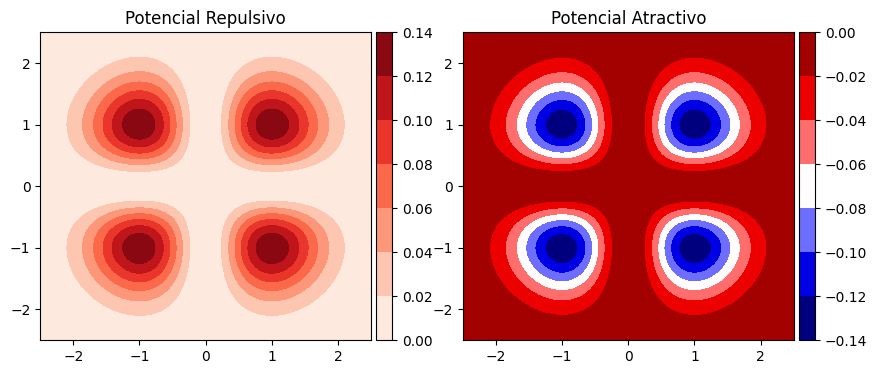

In [3]:
#Creación de arrays 1D

x = np.linspace(-2.5, 2.5, 1000)
y = np.linspace(-2.5,2.5,1000)

#Creación de malla 2D y de ambos potenciales

xv, yv = np.meshgrid(x,y)
z1 =  xv ** 2 * yv ** 2 * np.exp(-(xv ** 2 + yv ** 2))
z2 = - xv ** 2 * yv ** 2 * np.exp(-(xv ** 2 + yv ** 2))

#Plotteo 

fig, ax = plt.subplots(1,2, figsize = (10,4))

repulsivo = ax[0].contourf(xv,yv,z1, cmap = "Reds")
ax[0].set_title("Potencial Repulsivo")
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(repulsivo, cax=cax, orientation='vertical')

atractivo = ax[1].contourf(xv,yv,z2, cmap = "seismic")
ax[1].set_title("Potencial Atractivo")
divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(atractivo, cax=cax, orientation='vertical')

plt.show()


Observamos que los máximos y mínimos coinciden espacialmente para ambos potenciales, gráficamente podemos aproximarlos a los puntos (-1,-1), (-1, 1), (1, -1), (1, 1). La forma de los potenciales es la misma, solamente transformamos zonas de máximos en zonas de mínimos y vice versa.

## b) Demostrar la forma de las ecuaciones de movimiento
Comenzamos con la definición de potencial:
$$\vec{F} = -\nabla \phi = - \frac{\partial\phi}{\partial x}\hat{x} - \frac{\partial\phi}{\partial y}\hat{y}$$
Por la simetría en el potencial para el intercambio $x\rightarrow y$, podemos calcular una de las derivadas aplicando la derivada de una suma y la regla de la cadena:
$$\frac{\partial}{\partial x} (\pm x^2 y^2 e ^{- (x^2 + y^2)}) = \pm y^2 (2xe^{- (x^2 + y^2)}+x^2e^{- (x^2 + y^2)}(-2x))$$
$$=\mp 2xy^2 e^{- (x^2 + y^2)}(1 - x^2)$$
Intercambiando x por y se obtiene la otra componente y, aplicando la segunda ley de newton $\vec{F} = m\vec{a}$, se obtiene el siguiente sistema de ecuaciones diferenciales acopladas:
$$m\frac{d^2 x}{dt^2} = \mp 2y^2 x ( 1 - x^2) e^{-(x^2 + y^2)}$$
$$m\frac{d^2 y}{dt^2} = \mp 2x^2 y ( 1 - y^2) e^{-(x^2 + y^2)}$$

## c) Demuestre que la fuerza se anula en los puntos x = ±1 y y = ±1, es decir, en los máximos del potencial, donde el valor máximo es: $V_{max} = \pm e^{-2}$


Haciendo que la fuerza se anule, requerimos que $vec{F} = 0$, lo cual nos lleva a las ecuaciones:
$$\mp 2y^2 x (1 - x^2)e^{-(x^2 + y^2)} = 0$$
$$\mp 2x^2 y (1 - y^2)e^{-(x^2 + y^2)} = 0$$
Y llegamos que existen distintas situaciones para las cuales estos es cierto:
$$y^2 = 0,\quad x^2 = 0,\quad (1-x^2) = 0,\quad (1-y^2)=0$$
Gracias a la información obtenida visualmente, se sabe que los puntos extremos no se encuentran en $x=0,\ y=0$. De manera que estos están en:
$$1-x^2=0\rightarrow x=\pm 1,\qquad 1-y^2=0\rightarrow y=\pm 1$$
El potencial en estos puntos $V(1,1)=\pm 2e^{-2}$

## d) Aplique el método de Runge-Kutta de cuarto orden (RK4) para resolver las ecuaciones diferenciales ordinarias de segundo orden.

In [3]:
# Definimos los parámetros constantes

m = 0.5
x = [0.05, -5, 0, 0.5] #Estado en el orden [x, y, vx, vy]

b = 0.05
impacto = np.zeros(41) #Array de parámetros de impacto para simular múltiples condiciones iniciales
suma = 0
for l in range(41): #Creación del array con las condiciones iniciales
    suma = -1 + l * b
    impacto[l] = suma

def f_rep(t, x):
    """Función para modelar el sistema de ecuaciones diferenciales acopladas asociadas a la fuerza"""
    ddxddt =  - 2 * x[1] ** 2 * x[0] * (1 - x[0] ** 2) * np.exp(-(x[0] ** 2 + x[1] ** 2)) / m
    dxdt = x[2] 
    ddyddt =  - 2 * x[0] ** 2 * x[1] * (1 - x[1] ** 2) * np.exp(-(x[1] ** 2 + x[0] ** 2)) / m
    dydt = x[3]
    return np.array([dxdt, dydt, ddxddt, ddyddt], float)

def f_atr(t, x):
    """Función para modelar el sistema de ecuaciones diferenciales acopladas asociadas a la fuerza"""
    ddxddt =   2 * x[1] ** 2 * x[0] * (1 - x[0] ** 2) * np.exp(-(x[0] ** 2 + x[1] ** 2)) / m
    dxdt = x[2] 
    ddyddt =   2 * x[0] ** 2 * x[1] * (1 - x[1] ** 2) * np.exp(-(x[1] ** 2 + x[0] ** 2)) / m
    dydt = x[3]
    return np.array([dxdt, dydt, ddxddt, ddyddt], float)

def V(x):
    """Función para calcular el valor del potencial"""
    return - x[0] ** 2 * x[1] ** 2 * np.exp(- (x[0] ** 2 + x[1] ** 2))
def ke(x):
    """Función para calcular la energía cinética"""
    return m * (x[2] ** 2 + x[3] ** 2) / 2

#Parámetros para la simulación
t0 = 0
tf = 40
N = 1000
h = (tf - t0) / N

#Creación de arrays a llenar
tpoints = np.arange(0, tf, h)
dim = len(tpoints)
xpoints = np.zeros(dim)
vxpoints = np.zeros(dim)
ypoints = np.zeros(dim)
vypoints = np.zeros(dim)

## h) Grafique trayectorias en el espacio de fases [x(t), x˙(t)] y [y(t), y˙(t)]. ¿En qué difieren de las de estados ligados?

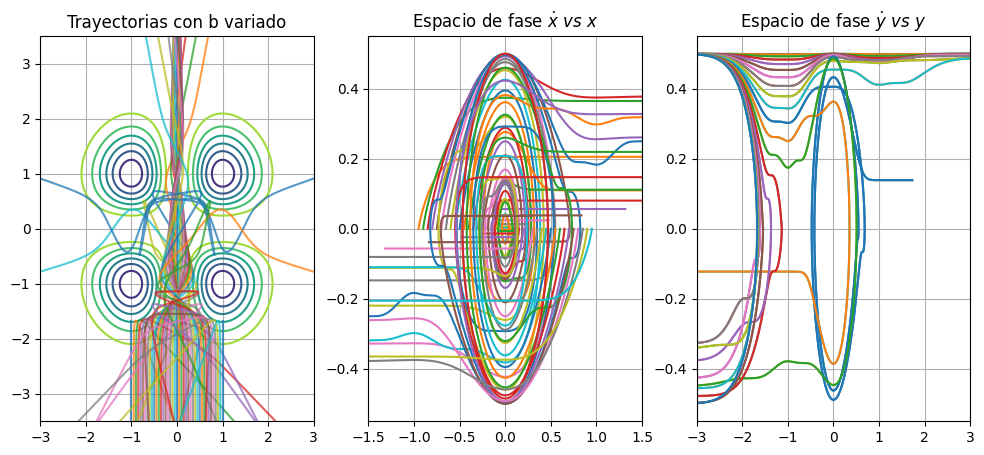

In [ ]:

#Plotteo de mapa de contorno 
xg = np.linspace(-2.5, 2.5, 1000)
yg = np.linspace(-2.5,2.5,1000)
xv, yv = np.meshgrid(xg,yg)
z = - xv ** 2 * yv ** 2 * np.exp(-(xv ** 2 + yv ** 2))

#Plotteo para potencial repulsivo
fig, ax = plt.subplots(1, 3, figsize = (12, 5))
ax[0].contour(xv,yv,z)
ax[0].set_ylim(-3.5,3.5)
ax[0].set_xlim(-3,3)
ax[0].grid()
ax[0].set_title("Trayectorias con b variado")
#ax[1].set_ylim(-3.5,3.5)
ax[1].set_xlim(- 1.5, 1.5)
ax[1].grid()
ax[1].set_title(r"Espacio de fase $\dot{x}\ vs\ x$")
#ax[1].set_ylim(-3.5,3.5)
ax[2].set_xlim(- 3, 3)
ax[2].grid()
ax[2].set_title(r"Espacio de fase $\dot{y}\ vs\ y$")
indices = []
angulos = []

#Aplicación del método Runge-Kutta
for j in range(len(impacto)):
    y0 = x.copy()
    y0[0] = impacto[j]
    
    for i in range(dim):
        xpoints[i] = y0[0]
        ypoints[i] = y0[1]
        vxpoints[i] = y0[2]
        vypoints[i] = y0[3]
        #print(xpoints[i])
        y0 = fc.rk4(tpoints[i], h, y0, f_rep)             
    ax[0].plot(xpoints, ypoints, alpha = 0.75)
    ax[1].plot(xpoints, vxpoints)
    ax[2].plot(ypoints, vypoints)
    

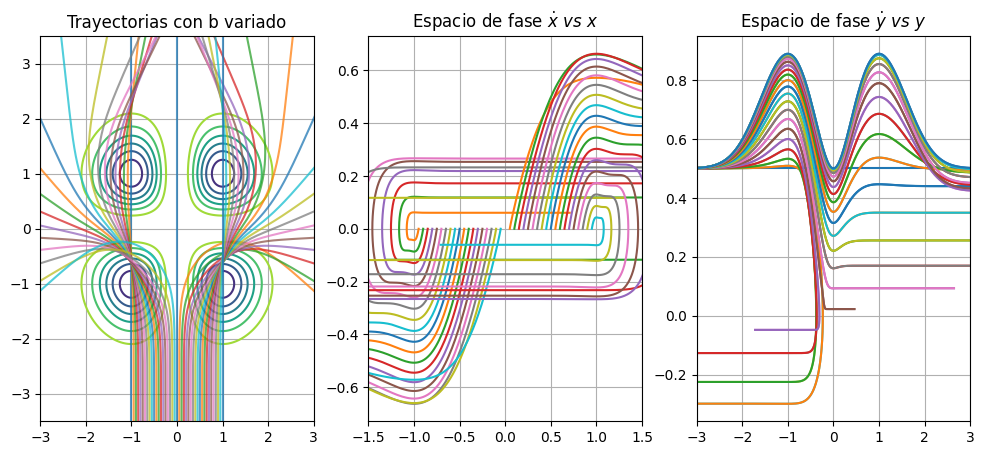

In [49]:
#Plotteo de mapa de contorno 
xg = np.linspace(-2.5, 2.5, 1000)
yg = np.linspace(-2.5,2.5,1000)
xv, yv = np.meshgrid(xg,yg)
z = - xv ** 2 * yv ** 2 * np.exp(-(xv ** 2 + yv ** 2))

#Plotteo para potencial atractivo
fig, ax = plt.subplots(1, 3, figsize = (12, 5))
ax[0].contour(xv,yv,z)
ax[0].set_ylim(-3.5,3.5)
ax[0].set_xlim(-3,3)
ax[0].grid()
ax[0].set_title("Trayectorias con b variado")
#ax[1].set_ylim(-3.5,3.5)
ax[1].set_xlim(- 1.5, 1.5)
ax[1].grid()
ax[1].set_title(r"Espacio de fase $\dot{x}\ vs\ x$")
#ax[1].set_ylim(-3.5,3.5)
ax[2].set_xlim(- 3, 3)
ax[2].grid()
ax[2].set_title(r"Espacio de fase $\dot{y}\ vs\ y$")
indices = []
angulos = []

#Aplicación del método Runge-Kutta
for j in range(len(impacto)):
    y0 = x.copy()
    y0[0] = impacto[j]
    
    for i in range(dim):
        xpoints[i] = y0[0]
        ypoints[i] = y0[1]
        vxpoints[i] = y0[2]
        vypoints[i] = y0[3]
        #print(xpoints[i])
        y0 = fc.rk4(tpoints[i], h, y0, f_atr)             
    ax[0].plot(xpoints, ypoints, alpha = 0.75)
    ax[1].plot(xpoints, vxpoints)
    ax[2].plot(ypoints, vypoints)

## i) Calcule el ángulo de dispersión:
$$\theta = atan2(v_x,v_y)$$
determinando las componentes de la velocidad cuando la partícula haya salido de la región de interacción (PE/KE ≤ 10−6).

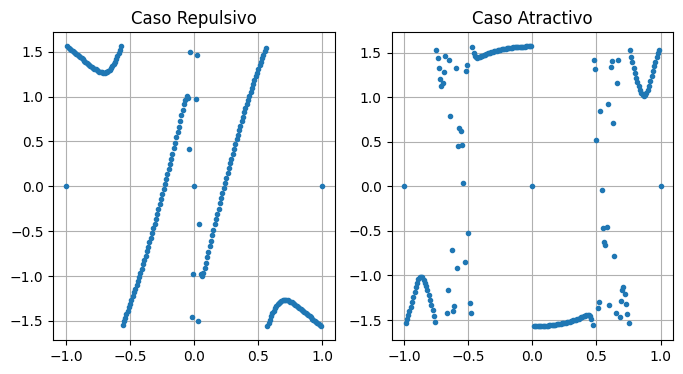

In [7]:
#Simulación de trayectorias para el cálculo de ángulos de dispersión

#creación de arrays para acumulación de ángulos
angulos_atr = []
angulos_rep = []
b = 0.01
impacto = np.zeros(201) #Array de parámetros de impacto para simular múltiples condiciones iniciales

tpoints = np.zeros(dim)
xpoints1 = np.zeros(dim)
xpoints2 = np.zeros(dim)
ypoints1 = np.zeros(dim)
ypoints2 = np.zeros(dim)

for l in range(201): #Creación del array con las condiciones iniciales
    suma = -1 + l * b
    impacto[l] = suma

fig, ax = plt.subplots(1,2, figsize = (8,4))
for j in range(len(impacto)):
    y0 = x.copy()
    y0[0] = impacto[j]
    z0 = w0 = y0
    
    z0 = w0 = y0 #Estados para los casos repulsivo y atractivo
    for i in range(dim):
        xpoints1[i] = z0[0]
        ypoints1[i] = z0[1]
        xpoints2[i] = w0[0]
        ypoints2[i] = w0[1]
        z0 = fc.rk4(tpoints[i], h, z0, f_rep)
        w0 = fc.rk4(tpoints[i], h, w0, f_atr)
    if z0[2] != 0:
        angulo_atr = np.atan(2 * z0[3] / z0[2])
        angulos_atr.append(angulo_atr)
    else:
        angulos_atr.append(0)
    if w0[2] != 0:
        angulo_rep = np.atan(2 * w0[3] / w0[2])
        angulos_rep.append(angulo_rep)
    else:
        angulos_rep.append(0)
ax[0].plot(impacto, angulos_rep, '.')
ax[0].grid()
ax[0].set_title('Caso Repulsivo')
ax[1].plot(impacto, angulos_atr, '.')
ax[1].grid()
ax[1].set_title('Caso Atractivo')
plt.show()



## j) ¿Qué características de las trayectorias conducen a discontinuidades en dθ/db y por tanto en la sección eficaz de dispersión σ(θ)?
Discontinuidades en $d\theta / db$ se generan cuando no existe un límite para $\theta (b)$ como es el caso cuando la gráfica salta entre dos posiciones de manera brusca. Debido a la simetría, podemos mencionar solo las zonas a uno de los lados de $b = 0$ asumiendo que el caso es el mismo para su opuesto.
- Para el caso repulsivo, existen discontinuidades cerca de $b = -0.5$ y $b = 0$, que son zonas donde una pequeña variación en el parámetro de impacto causan que los ángulos de dispersión cambien bruscamente.
- Para el caso atractivo, se tiene una zona entre aproximadamente $b = -0.75$ y $b = -0.5$, las cuales corresponden a interacciones con más de uno de los extremos del potencial dando lugar a varianzas causadas por lograr interactuar con uno o dos extremos.

## k) Realice simulaciones tanto para el potencial atractivo como para el repulsivo, y para energías menores y mayores que: $V_{max} = e^{-2}$

Prestando atención a los mapas de calor, en términos de posición las gráficas realizadas en el literal h poseen una energía total de:

In [27]:
E = V(x) + ke(x)
print(f"La energía total para el estado inicial es {E}, siendo el valor máximo del potencial {np.exp(-2)}")

La energía total para el estado inicial es 0.06249999999913417, siendo el valor máximo del potencial 0.1353352832366127


De manera que ya tenemos el caso de energía menor al máximo de V y trabajamos energías mayores.
$$v = \sqrt{2 * 0.14 / m} = $$

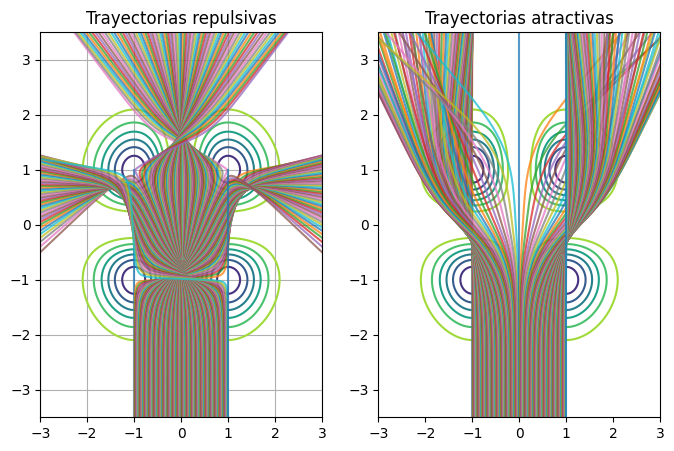

In [33]:
#Planteamos un estado cuya energía cinética sea mayor que 0.13
x = [0, -5, 0, np.sqrt(2 * np.exp(-2) / m)]
xg = np.linspace(-2.5, 2.5, 1000)
yg = np.linspace(-2.5,2.5,1000)
xv, yv = np.meshgrid(xg,yg)
z = - xv ** 2 * yv ** 2 * np.exp(-(xv ** 2 + yv ** 2))
xpoints1 = np.zeros(dim)
xpoints2 = np.zeros(dim)
ypoints1 = np.zeros(dim)
ypoints2 = np.zeros(dim)
#Plotteo para potencial atractivo y repulsivo
fig, ax = plt.subplots(1, 2, figsize = (8, 5))
ax[0].contour(xv,yv,z)
ax[0].set_ylim(-3.5,3.5)
ax[0].set_xlim(-3,3)
ax[0].grid()
ax[0].set_title("Trayectorias repulsivas")
#ax[1].set_ylim(-3.5,3.5)
ax[1].contour(xv,yv,z)
ax[1].set_ylim(-3.5,3.5)
ax[1].set_xlim(-3,3)
ax[1].set_title(r"Trayectorias atractivas")


#Aplicación del método Runge-Kutta
for j in range(len(impacto)):
    y0 = x.copy()
    y0[0] = impacto[j]
    z0 = y0
    w0 = y0
    for i in range(dim):
        xpoints1[i] = z0[0]
        ypoints1[i] = z0[1]
        xpoints2[i] = w0[0]
        ypoints2[i] = w0[1]
        #print(xpoints[i])
        z0 = fc.rk4(tpoints[i], h, z0, f_rep)             
        w0 = fc.rk4(tpoints[i], h, w0, f_atr)
    ax[0].plot(xpoints1, ypoints1, alpha = 0.75)
    ax[1].plot(xpoints2, ypoints2, alpha = 0.75)
    

Comparado con los casos anteriores, se observa la falta de dispersiones o distorciones en las trayectorias cuando se acerca a los extremos inferiores, explicados como insignificancia en el papel que juega la obtención de energía potencial al ser esta menor que la cinética.